In [1]:
import torch 
import torch.nn as nn
import numpy as np
from torch.nn import Parameter
import torch.nn.functional as F
import torch.optim as optim
from sklearn import metrics
import os
from tqdm import tqdm


from torch_geometric.utils import to_undirected, subgraph
from torch_geometric.data import Data, Batch, DataLoader

from config import config_train, config_test
from data_process import data_process_all_chrom, data_process

import models
from sampler import *
from aggregator import MaxminMeanAggregator

import utils
from batch import load_val

/public/home/wuyy/miniconda3/envs/torch/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


In [3]:
dim_edge = 400
dim_vertex = 400

alpha_e = 0
alpha_v = 0

input_dim = 15 #features_num

n_layers = 1

size = 1000
nv = size

memory_size = 0

lr = 0.00004

bs = 512

memory_size = 0
clip = 0.01
n_layers = 3


In [4]:
model_dir = 'models/K562/'

model = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model.to(device)

if model_dir:
    model.load_state_dict(torch.load(model_dir+"model_epoch_9"))

    
cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator.to(device)

if model_dir:
    Aggregator.load_state_dict(torch.load(model_dir+"Aggregator_epoch_9"))

In [5]:
import pickle

chr_name = "chr14"

with open("chrom_data/K562/"+chr_name+"_sliding_data","rb") as f:
    sliding_data = pickle.load(f)

In [6]:
data = sliding_data[15]

In [7]:
with open("K562","rb") as f:
    annotate = pickle.load(f)
    
anno = annotate["chr14"][15]

with open("ABcom/K562/chr14_compartments","rb") as f:
    ABcom = pickle.load(f)

In [8]:
anno[0]*5000

91020000

In [9]:
ABlabels = []

ABnum = {"A":0 , "B":1 , "NA": 2}

for a in anno:
    ABlabels.append(ABnum[ABcom[a]])

In [10]:
data = data.to(device)

In [11]:
v = model(data.x, data.edge_index, data.edge_attr)

In [12]:
labels = list(range(1, 1001))

In [13]:
from torch.utils.tensorboard import SummaryWriter

path = "/public/home/wuyy/embeddings/mp5"

# default `log_dir` is "runs" - we'll be more specific here
writer = SummaryWriter(path)
writer.add_embedding(v,metadata=labels)
writer.close()

In [15]:
def model_eval(data, test_batchloader, model, Aggregator):
    model.eval()
    Aggregator.eval()
    with torch.no_grad():
        total_pred = []
        test_label = []
        num_data = 0

        v = model(data.x, data.edge_index, data.edge_attr)
        
        while True :
            hedges, labels, is_last = test_batchloader.next()
            batch_size = len(hedges)
            num_data+=batch_size
            for hedge in hedges :
                embeddings = v[hedge]
                #pred, _ = Aggregator(embeddings)
                max_min_dist = torch.max(hedge) - torch.min(hedge)
                pred, _ = Aggregator(max_min_dist,embeddings)
                total_pred.append(pred.detach())
                test_label.append(hedge.detach().cpu().tolist())
            
            if is_last :
                break
        total_pred = torch.stack(total_pred)       
        total_pred = total_pred.squeeze()
        #test_label = torch.cat(test_label, dim=0)
        

    return total_pred.tolist(), test_label

In [28]:
with open("chrom_data/K562/chr14_sliding_data","rb") as f:
        sliding_data = pickle.load(f)

In [29]:
data = sliding_data[15]

In [30]:
####Random walk
import random
from torch_cluster import random_walk
import torch
import utils


size_dist_all = {}

for data_ in sliding_data: ####1
    size_dist = utils.gen_size_dist(data_.hyper_edge)
    
    for k, v in size_dist.items():
        
        if k in size_dist_all.keys():
            size_dist_all[k].append(v)
        else:
            size_dist_all[k] = [v]

sums = 0
for i in list(size_dist_all.values()):
    sums = sums + np.mean(i)            
            
size_dist_mean = {}

for k, v in size_dist_all.items():
    size_dist_mean[k] = np.mean(v)/sums


p_dict = size_dist_mean

data = data.to(device)

points = list(range(1000))

num_experiments = 12000000#5000000

rands = []

for _ in range(num_experiments):
    num_samples = random.choices(list(p_dict.keys()), weights=list(p_dict.values()))[0]
    sampled_start = random.choices(points, k=1)
    
    start = torch.tensor(sampled_start).to(device)
    walk = random_walk(data.edge_index[0], data.edge_index[1], start, num_samples-1, num_nodes=data.num_nodes)
    walk = walk.cpu().tolist()[0]
    
    rands.append(tuple(set(walk)))

In [31]:
test_batchloader = load_val(rands, bs, device, label="rand")
val_pred_rand, total_label_rand = model_eval(data, test_batchloader, model, Aggregator)

In [32]:
results = []
ps = []

switch = 'rand'


if switch == 'rand':

    for v in range(0,len(val_pred_rand)):
        if val_pred_rand[v] > 0.88:
            results.append(rands[v])
            ps.append(val_pred_rand[v])

In [33]:
len(results)

142726

In [34]:
random_elements = random.sample(results, len(data.hyper_edge))

In [35]:
results = random_elements

In [36]:
len(data.hyper_edge)

75854

In [37]:
from itertools import combinations

res = []
for i in range(0,len(results)):
    r = results[i]
    for (a1, a2) in combinations(r, 2):
        res.append([a1,a2,1])
        
f2 = np.full((1000, 1000), np.nan)

res_dict = {}

for r in res:
    if (r[0],r[1]) in res_dict.keys():
        res_dict[(r[0],r[1])].append(r[2])
        res_dict[(r[1],r[0])].append(r[2])
    else:
        res_dict[(r[0],r[1])] = [r[2]]
        res_dict[(r[1],r[0])] = [r[2]]

for k, v in res_dict.items():
    f2[k[0],k[1]] = np.sum(v)

In [38]:
import json

# 从文件中读取JSON数据
with open('statek.txt', 'r') as file:
    jdata = json.load(file)

umap_coordinates = []

# 遍历每个对象，提取"umap-0"和"umap-1"的坐标
for item in jdata[0]['projections']:
    umap_coords = [item['umap-0'], item['umap-1']]
    umap_coordinates.append(umap_coords)


umap_coordinates = np.array(umap_coordinates)


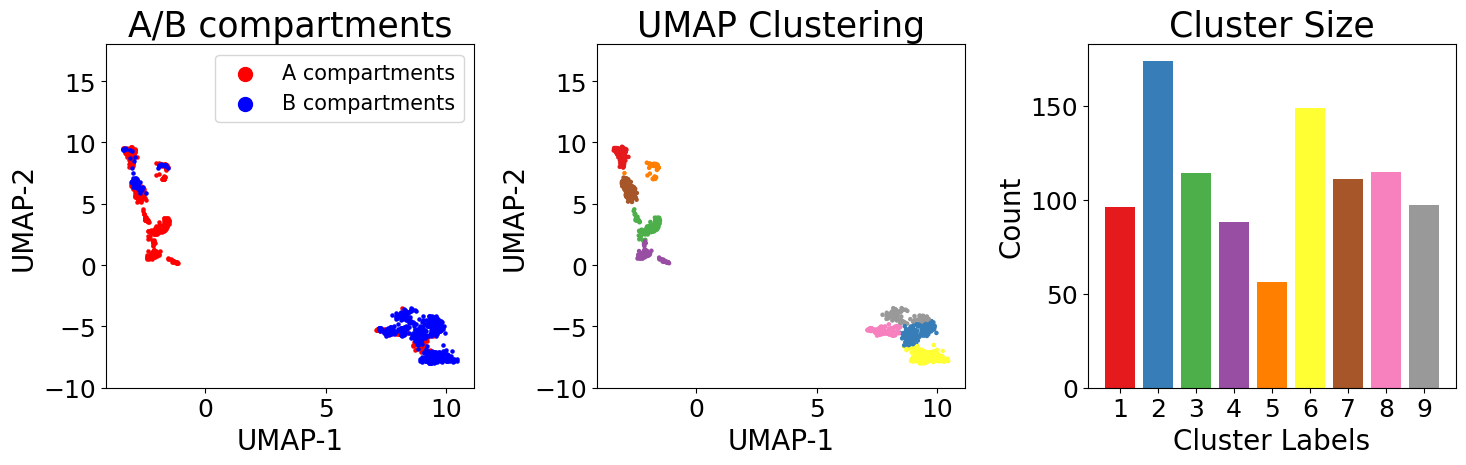

In [39]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


plt.rcParams.update({'font.size': 18})

num_clusters = 9
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(umap_coordinates)

# 获取每个簇的中心点
centers = kmeans.cluster_centers_

# 预测每个数据点所属的簇
labels = kmeans.labels_

# 绘制散点图
plt.figure(figsize=(15, 5))  # 设置图的大小

# 绘制散点图
plt.subplot(132)
plt.scatter(umap_coordinates[:, 0], umap_coordinates[:, 1], s=5, c=labels, cmap='Set1')  # 绘制散点图

# for i in range(len(centers)):
#     plt.text(centers[i, 0], centers[i, 1], str(i), ha='right', va='bottom', fontsize=15, color='red')
    
plt.xlabel('UMAP-1', fontsize=20)
plt.ylabel('UMAP-2', fontsize=20)
plt.title('UMAP Clustering', fontsize=25)
#plt.legend(fontsize=10)  # 显示图例
#plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # 添加网格线
plt.ylim((-10,18))


# 绘制柱状图
plt.subplot(133)
unique_labels, counts = np.unique(labels, return_counts=True)  # 计算每个簇的数量
plt.bar(unique_labels, counts, color=plt.cm.Set1(np.linspace(0, 1, num_clusters))) #Set2 # 根据标签绘制柱状图，使用viridis颜色映射
plt.xlabel('Cluster Labels', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(np.arange(0,len(unique_labels)),np.array(unique_labels)+1)
plt.title('Cluster Size', fontsize=25)
#plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)  # 添加水平网格线



plt.subplot(131)
ABlabels = np.array(ABlabels)

group_0 = umap_coordinates[ABlabels == 0]
group_1 = umap_coordinates[ABlabels == 1]

# 绘制两类散点图
plt.scatter(group_0[:, 0], group_0[:, 1], s=5, c='red', label='A compartments')
plt.scatter(group_1[:, 0], group_1[:, 1], s=5, c='blue', label='B compartments')
plt.xlabel('UMAP-1', fontsize=20)
plt.ylabel('UMAP-2', fontsize=20)
plt.title('A/B compartments', fontsize=25)
plt.ylim((-10,18))

# 显示图例

legend = plt.legend(fontsize=15)
legend.legendHandles[0]._sizes = [100]
legend.legendHandles[1]._sizes = [100]

plt.tight_layout()  # 调整布局

plt.savefig('umap1.png', dpi=300)

plt.show()

In [40]:
from itertools import combinations

results = data.hyper_edge

res = []
for i in range(0,len(results)):
    r = results[i]
    for (a1, a2) in combinations(r, 2):
        res.append([a1,a2,1])

f = np.full((1000, 1000), np.nan)

res_dict = {}

for r in res:
    if (r[0],r[1]) in res_dict.keys():
        res_dict[(r[0],r[1])].append(r[2])
        res_dict[(r[1],r[0])].append(r[2])
    else:
        res_dict[(r[0],r[1])] = [r[2]]
        res_dict[(r[1],r[0])] = [r[2]]

for k, v in res_dict.items():
    f[k[0],k[1]] = np.sum(v)

In [41]:
# f = np.full((1000, 1000), np.nan)

# # plot hic
# for i in range(0,data.edge_index.shape[1]):
#     k0 = data.edge_index[0,i]
#     k1 = data.edge_index[1,i]
#     f[k0, k1] = data.edge_attr[i]

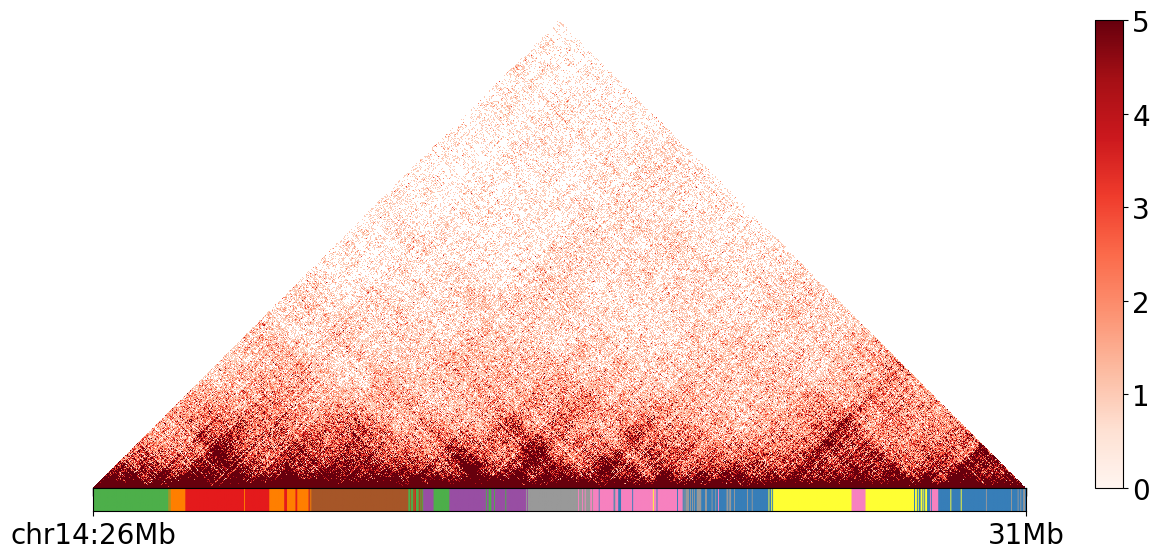

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from itertools import combinations
import itertools
from matplotlib.gridspec import GridSpec


plt.rcParams.update({'font.size': 20})


def pcolormesh_45deg(ax, matrix_c, start_pos_vector, start, end):
    
    n = matrix_c.shape[0]
    # create rotation/scaling matrix
    t = np.array([[1, 0.5], [-1, 0.5]])
    # create coordinate matrix and transform it
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                            start_pos_vector)]), t)
    
    # this is to convert the indices into bp ranges
    x = matrix_a[:, 1].reshape(n , n )
    y = matrix_a[:, 0].reshape(n , n )
    
    cmap = plt.cm.Reds#coolwarm
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.5, vmax=5) #vcenter=0.7,

    #plt.imshow(hic_data[:,:], cmap=cmap,norm=norm,  interpolation='nearest')
    
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), cmap=cmap,norm=norm)
    
    ax.set_xlim(-0.5, n)
    ax.set_xticks([-0.5, n])
    ax.set_xticklabels([start, end], fontsize=20)
    ax.tick_params(axis='x',which='major',direction='out',bottom=True,length=6, width = 1)
    
    ax.set_ylim(0, n)
    
    #ax.xaxis.set_ticks_position('bottom') 
    #ax.tick_params(length=6, width=2, direction='inout')
    
    # Hide y-axis
    # Hide y-axis and spines
    ax.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)   
    
    return im

gs = GridSpec(nrows=2, ncols=2, width_ratios = (10,0.3), height_ratios=[10, 0.5])
fig = plt.figure(figsize=(12,6))

ax1 = fig.add_subplot(gs[0,0])

matrix_size = f.shape[0]    
triangle_matrix = np.triu(f)

# 创建一个掩码，将下半部分设为 False
mask = np.tri(matrix_size, k=-1)
masked_matrix = np.ma.array(triangle_matrix, mask=mask)

# 调用 pcolormesh_45deg() 方法绘制旋转后的矩阵
im = pcolormesh_45deg(ax1, masked_matrix, np.arange(matrix_size), 'chr14:26Mb', '31Mb')


ax2 = fig.add_subplot(gs[1,0],sharex=ax1)


unique_labels = np.unique(labels)
num_clusters = len(unique_labels)

# Map unique labels to values in the range [0, 1]
label_to_value = {label: value for label, value in zip(unique_labels, np.linspace(0, 1, num_clusters))}

# Map labels to their respective values
label_values = np.array([label_to_value[label] for label in labels])

# 生成第二个图
colors = plt.cm.Set1(label_values)  # 根据标签创建颜色
ax2.imshow([colors], aspect='auto')
ax2.get_yaxis().set_visible(False)

plt.setp(ax1.get_xticklabels(), visible=False)

cax = fig.add_subplot(gs[0,1])
plt.colorbar(im, cax=cax)


plt.tight_layout()
plt.subplots_adjust(hspace=.0)

plt.savefig('umap2.png', dpi=300)

plt.show()

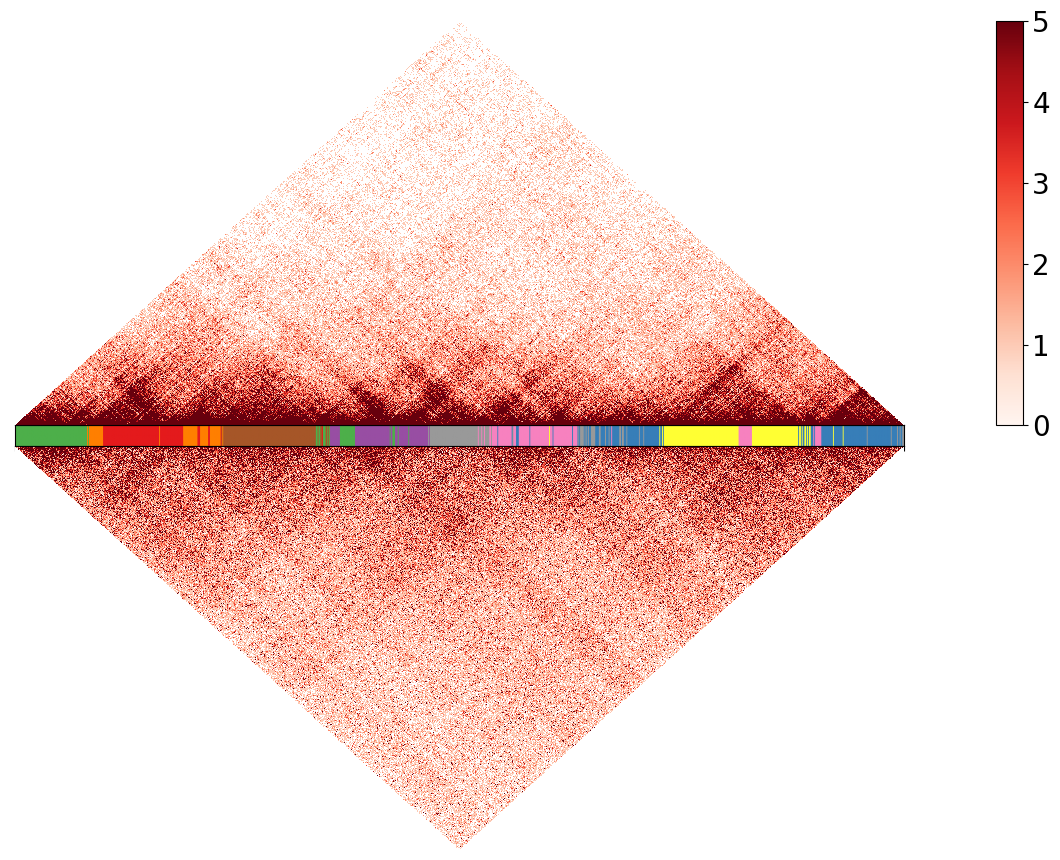

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from itertools import combinations
import itertools
from matplotlib.gridspec import GridSpec

plt.rcParams.update({'font.size': 20})

def pcolormesh_45deg(ax, matrix_c, start_pos_vector, start, end):
    n = matrix_c.shape[0]
    t = np.array([[1, 0.5], [-1, 0.5]])
    matrix_a = np.dot(np.array([(i[1], i[0]) for i in itertools.product(start_pos_vector[::-1], start_pos_vector)]), t)
    x = matrix_a[:, 1].reshape(n, n)
    y = matrix_a[:, 0].reshape(n, n)
    cmap = plt.cm.Reds
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.5, vmax=5)
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), cmap=cmap, norm=norm)
    ax.set_xlim(-0.5, n)
    #ax.set_xticks([-0.5, n])
    #ax.set_xticklabels([start, end], fontsize=20)
    ax.tick_params(axis='x', which='major', direction='out', bottom=True, length=6, width=1)
    ax.set_ylim(0, n)
    ax.get_yaxis().set_visible(False)
    ax.get_xaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return im

def pcolormesh_135deg(ax, matrix_c, start_pos_vector, start, end):
    n = matrix_c.shape[0]
    t = np.array([[1, 0.5], [-1, 0.5]])
    matrix_a = np.dot(np.array([(i[1], i[0]) for i in itertools.product(start_pos_vector, start_pos_vector)]), t)
    x = matrix_a[:, 1].reshape(n, n)
    y = matrix_a[:, 0].reshape(n, n)

    cmap = plt.cm.Reds
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.5, vmax=5)
    im = ax.pcolormesh(x, y, matrix_c, cmap=cmap, norm=norm)
    ax.set_xlim(-0.5, n)
    #ax.set_xticks([-0.5, n])
    #ax.set_xticklabels([start, end], fontsize=20)
    ax.tick_params(axis='x', which='major', direction='out', bottom=True, length=6, width=1)
    ax.set_ylim(-n, 1)
    ax.get_yaxis().set_visible(False)
    ax.get_xaxis().set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return im


gs = GridSpec(nrows=3, ncols=2, width_ratios=(10, 0.3), height_ratios=[10, 0.5, 10])
fig = plt.figure(figsize=(11, 9))

ax2 = fig.add_subplot(gs[1, 0])

ax1 = fig.add_subplot(gs[0, 0], sharex=ax2)

# Your matrix and plotting code for ax1...
matrix_size = f.shape[0]
triangle_matrix = np.triu(f)
mask = np.tri(matrix_size, k=-1)
masked_matrix = np.ma.array(triangle_matrix, mask=mask)
im1 = pcolormesh_45deg(ax1, masked_matrix, np.arange(matrix_size), 'chr14:26Mb', '31Mb')


ax3 = fig.add_subplot(gs[2, 0], sharex=ax2)

# Plotting code for ax3 (similar to ax1 but flipped vertically)...
matrix_size = f2.shape[0]
triangle_matrix = np.tril(f2)
mask = 1 - np.tri(matrix_size, k=1)
masked_matrix_flipped = np.ma.array(triangle_matrix, mask=mask)
im3 = pcolormesh_135deg(ax3, masked_matrix_flipped, np.arange(matrix_size), 'chr14:26Mb', '31Mb')


# Your labeling and plotting code for ax2...
unique_labels = np.unique(labels)
num_clusters = len(unique_labels)
label_to_value = {label: value for label, value in zip(unique_labels, np.linspace(0, 1, num_clusters))}
label_values = np.array([label_to_value[label] for label in labels])
colors = plt.cm.Set1(label_values) #Set1
ax2.imshow([colors], aspect='auto')
ax2.set_xticklabels(['1','2'])
ax2.get_yaxis().set_visible(False)


plt.setp(ax2.get_xticklabels(), visible=False)
ax2.get_yaxis().set_visible(False)

cax = fig.add_subplot(gs[0, 1])
plt.colorbar(im1, cax=cax)


plt.tight_layout()
plt.subplots_adjust(wspace=0.20, hspace=.0)

plt.savefig('umap2.png', dpi=300)

plt.show()


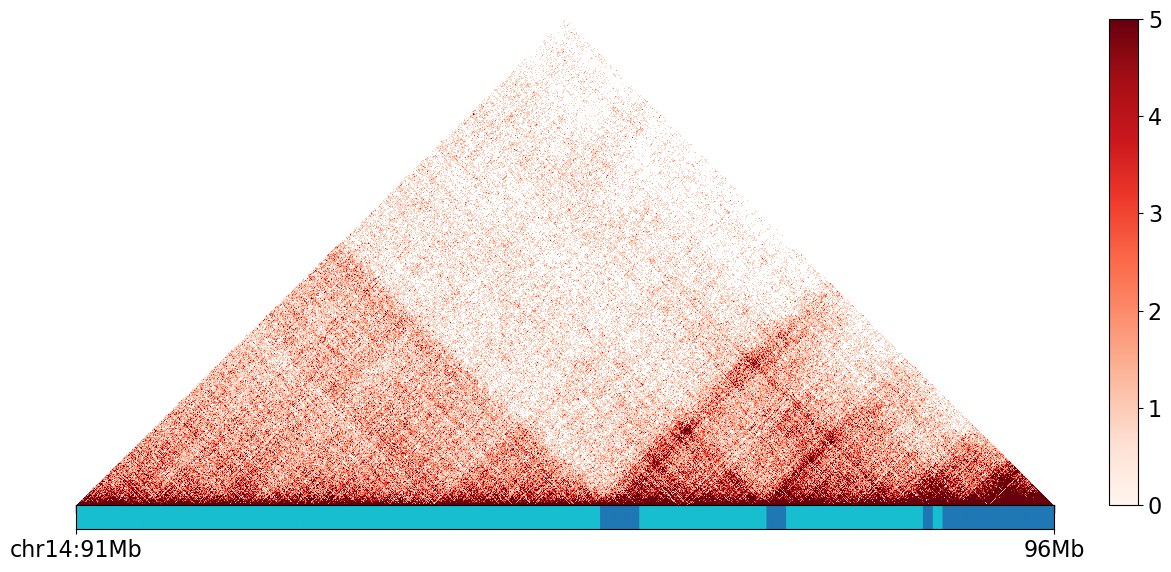

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from itertools import combinations
import itertools
from matplotlib.gridspec import GridSpec


plt.rcParams.update({'font.size': 16})


def pcolormesh_45deg(ax, matrix_c, start_pos_vector, start, end):
    
    n = matrix_c.shape[0]
    # create rotation/scaling matrix
    t = np.array([[1, 0.5], [-1, 0.5]])
    # create coordinate matrix and transform it
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                            start_pos_vector)]), t)
    
    # this is to convert the indices into bp ranges
    x = matrix_a[:, 1].reshape(n , n )
    y = matrix_a[:, 0].reshape(n , n )
    
    cmap = plt.cm.Reds#coolwarm
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.5, vmax=5) #vcenter=0.7,

    #plt.imshow(hic_data[:,:], cmap=cmap,norm=norm,  interpolation='nearest')
    
    
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), cmap=cmap,norm=norm)
    
    ax.set_xlim(-0.5, n)
    ax.set_xticks([-0.5, n])
    ax.set_xticklabels([start, end], fontsize=15)
    ax.tick_params(axis='x',which='major',direction='out',bottom=True,length=6, width = 1)
    
    ax.set_ylim(0, n)
    
    #ax.xaxis.set_ticks_position('bottom') 
    #ax.tick_params(length=6, width=2, direction='inout')
    
    # Hide y-axis
    # Hide y-axis and spines
    ax.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)   
    
    return im

gs = GridSpec(nrows=2, ncols=2, width_ratios = (10,0.3), height_ratios=[10, 0.5])
fig = plt.figure(figsize=(12,6))

ax1 = fig.add_subplot(gs[0,0])

matrix_size = f.shape[0]    
triangle_matrix = np.triu(f)

# 创建一个掩码，将下半部分设为 False
mask = np.tri(matrix_size, k=-1)
masked_matrix = np.ma.array(triangle_matrix, mask=mask)

# 调用 pcolormesh_45deg() 方法绘制旋转后的矩阵
im = pcolormesh_45deg(ax1, masked_matrix, np.arange(matrix_size), 'chr14:91Mb', '96Mb')


ax2 = fig.add_subplot(gs[1,0],sharex=ax1)

#labels = 
unique_labels = np.unique(ABlabels)
num_clusters = len(unique_labels)

# Map unique labels to values in the range [0, 1]
label_to_value = {label: value for label, value in zip(unique_labels, np.linspace(0, 1, num_clusters))}

# Map labels to their respective values
label_values = np.array([label_to_value[label] for label in ABlabels])

# 生成第二个图
colors = plt.cm.tab10(label_values)  # 根据标签创建颜色
ax2.imshow([colors], aspect='auto')
ax2.get_yaxis().set_visible(False)

plt.setp(ax1.get_xticklabels(), visible=False)

cax = fig.add_subplot(gs[0,1])
plt.colorbar(im, cax=cax)


plt.tight_layout()
plt.subplots_adjust(hspace=.0)

plt.savefig('umap2.png', dpi=300)

plt.show()

In [127]:
f

array([[nan, 17., 17., ..., nan, nan, nan],
       [17., nan, 32., ...,  1., nan, nan],
       [17., 32., nan, ..., nan, nan, nan],
       ...,
       [nan,  1., nan, ..., nan, 51., 53.],
       [nan, nan, nan, ..., 51., nan, 74.],
       [nan, nan, nan, ..., 53., 74., nan]])